# Análisis Exploratorio de Datos (EDA)
## Features extraídas desde representaciones tiempo-frecuencia

Este notebook explora y caracteriza los datasets de features generados en el
notebook anterior a partir de las representaciones STFT y CWT. El objetivo es
entender la estructura de los datos antes de cualquier análisis comparativo o
clasificación: verificar su integridad, visualizar las distribuciones por clase
y detectar patrones o problemas que informen las decisiones posteriores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# ── Rutas ─────────────────────────────────────────────────────────────────
STFT_PATH = './data/features/features_stft.csv'
CWT_PATH  = './data/features/features_cwt.csv'

for p in [STFT_PATH, CWT_PATH]:
    if not Path(p).exists():
        raise FileNotFoundError(f"Archivo no encontrado: {p}")

df_stft = pd.read_csv(STFT_PATH)
df_cwt  = pd.read_csv(CWT_PATH)

# ── Configuración ──────────────────────────────────────────────────────────
CHANNELS   = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
FEAT_NAMES = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
COL_NAMES  = [f'{ch}_{f}' for ch in CHANNELS for f in FEAT_NAMES]

# Canales occipitales y parietales — los más relevantes para el ritmo alfa
OCC_CHANNELS = ['O1', 'O2', 'P7', 'P8']

TECHNIQUES = [('STFT', df_stft), ('CWT', df_cwt)]

print(f"STFT — shape: {df_stft.shape}  |  NaN: {df_stft.isnull().sum().sum()}")
print(f"CWT  — shape: {df_cwt.shape}   |  NaN: {df_cwt.isnull().sum().sum()}")

STFT — shape: (236, 57)  |  NaN: 0
CWT  — shape: (236, 57)   |  NaN: 0


## Sección 1: Validación básica

Antes de cualquier análisis se verifica la integridad estructural de ambos
datasets: balance de clases, consistencia entre técnicas y estadísticas
descriptivas generales.

In [3]:
print("=" * 50)
print("BALANCE DE CLASES")
print("=" * 50)

for name, df in TECHNIQUES:
    counts = df['label'].value_counts().sort_index()
    total  = len(df)
    print(f"\n{name}:")
    for cls, n in counts.items():
        estado = "Ojos abiertos" if cls == 0 else "Ojos cerrados"
        print(f"  Clase {cls} ({estado}): {n:3d} ventanas  ({100*n/total:.1f}%)")

# Verificar que ambas técnicas tienen exactamente las mismas etiquetas
# (condición necesaria para que la comparación sea justa)
etiquetas_identicas = (df_stft['label'].values == df_cwt['label'].values).all()
print(f"\n¿Etiquetas idénticas entre STFT y CWT? {'SI' if etiquetas_identicas else 'NO'}")
print(f"Total de ventanas: {len(df_stft)}")
print(f"Duración efectiva analizada: {len(df_stft) * 2 / 60:.1f} min  "
      f"(ventanas de 2s sobre 117s de registro)")

BALANCE DE CLASES

STFT:
  Clase 0 (Ojos abiertos): 128 ventanas  (54.2%)
  Clase 1 (Ojos cerrados): 108 ventanas  (45.8%)

CWT:
  Clase 0 (Ojos abiertos): 128 ventanas  (54.2%)
  Clase 1 (Ojos cerrados): 108 ventanas  (45.8%)

¿Etiquetas idénticas entre STFT y CWT? SI
Total de ventanas: 236
Duración efectiva analizada: 7.9 min  (ventanas de 2s sobre 117s de registro)


### Estadísticas descriptivas por feature y clase

In [4]:
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS — canales occipitales (O1, O2, P7, P8)")
print("=" * 60)

for feat in FEAT_NAMES:
    print(f"\n── {feat} ──")
    header = f"{'Canal':<6} {'Técnica':<6} {'Clase 0 media':>14} {'Clase 1 media':>14} {'Clase 0 std':>12} {'Clase 1 std':>12}"
    print(header)
    print("-" * len(header))
    for ch in OCC_CHANNELS:
        col = f'{ch}_{feat}'
        for name, df in TECHNIQUES:
            m0 = df.loc[df['label']==0, col].mean()
            m1 = df.loc[df['label']==1, col].mean()
            s0 = df.loc[df['label']==0, col].std()
            s1 = df.loc[df['label']==1, col].std()
            print(f"{ch:<6} {name:<6} {m0:>14.4f} {m1:>14.4f} {s0:>12.4f} {s1:>12.4f}")

ESTADÍSTICAS DESCRIPTIVAS — canales occipitales (O1, O2, P7, P8)

── alpha_abs ──
Canal  Técnica  Clase 0 media  Clase 1 media  Clase 0 std  Clase 1 std
----------------------------------------------------------------------
O1     STFT           0.0486         0.0463       0.0273       0.0231
O1     CWT            2.4605         2.3597       0.9133       0.8131
O2     STFT           0.0635         0.0644       0.0392       0.0382
O2     CWT            3.2626         3.1710       1.3914       1.4210
P7     STFT           0.0372         0.0342       0.0231       0.0159
P7     CWT            1.9197         1.8098       0.7721       0.6061
P8     STFT           0.0679         0.0687       0.0436       0.0405
P8     CWT            3.4583         3.4805       1.5327       1.5176

── alpha_rel ──
Canal  Técnica  Clase 0 media  Clase 1 media  Clase 0 std  Clase 1 std
----------------------------------------------------------------------
O1     STFT           0.2934         0.2919       0.1020 

### Observaciones de las estadísticas descriptivas

- Las diferencias entre clases son pequeñas en todas las features y canales,
  consistente con el diagnóstico previo de contaminación por artefactos.
- El **centro de gravedad (CoG)** es la feature con dirección más consistente:
  clase 0 (ojos abiertos) presenta CoG levemente mayor que clase 1 (ojos
  cerrados), coherente con la mayor presencia de actividad beta en el estado
  de alerta visual.
- La **entropía espectral** es sistemáticamente más alta en CWT que en STFT
  (~0.94–0.96 vs ~0.84–0.86). Esto refleja que el espaciado logarítmico y el
  suavizado intrínseco del wavelet Morlet distribuyen la energía más
  uniformemente en el espectro — una diferencia metodológica real entre ambas
  representaciones, no un artefacto de cálculo.
- Las desviaciones estándar son grandes relativas a las diferencias de medias,
  anticipando baja separabilidad estadística. Esto se cuantificará formalmente
  en el notebook 05.

## Sección 2: Distribución de features por clase

Visualización de las distribuciones de cada feature en los canales occipitales
y parietales (O1, O2, P7, P8), comparando ojos abiertos vs cerrados y STFT vs
CWT en el mismo panel. Una buena separación entre distribuciones indica una
feature discriminante.

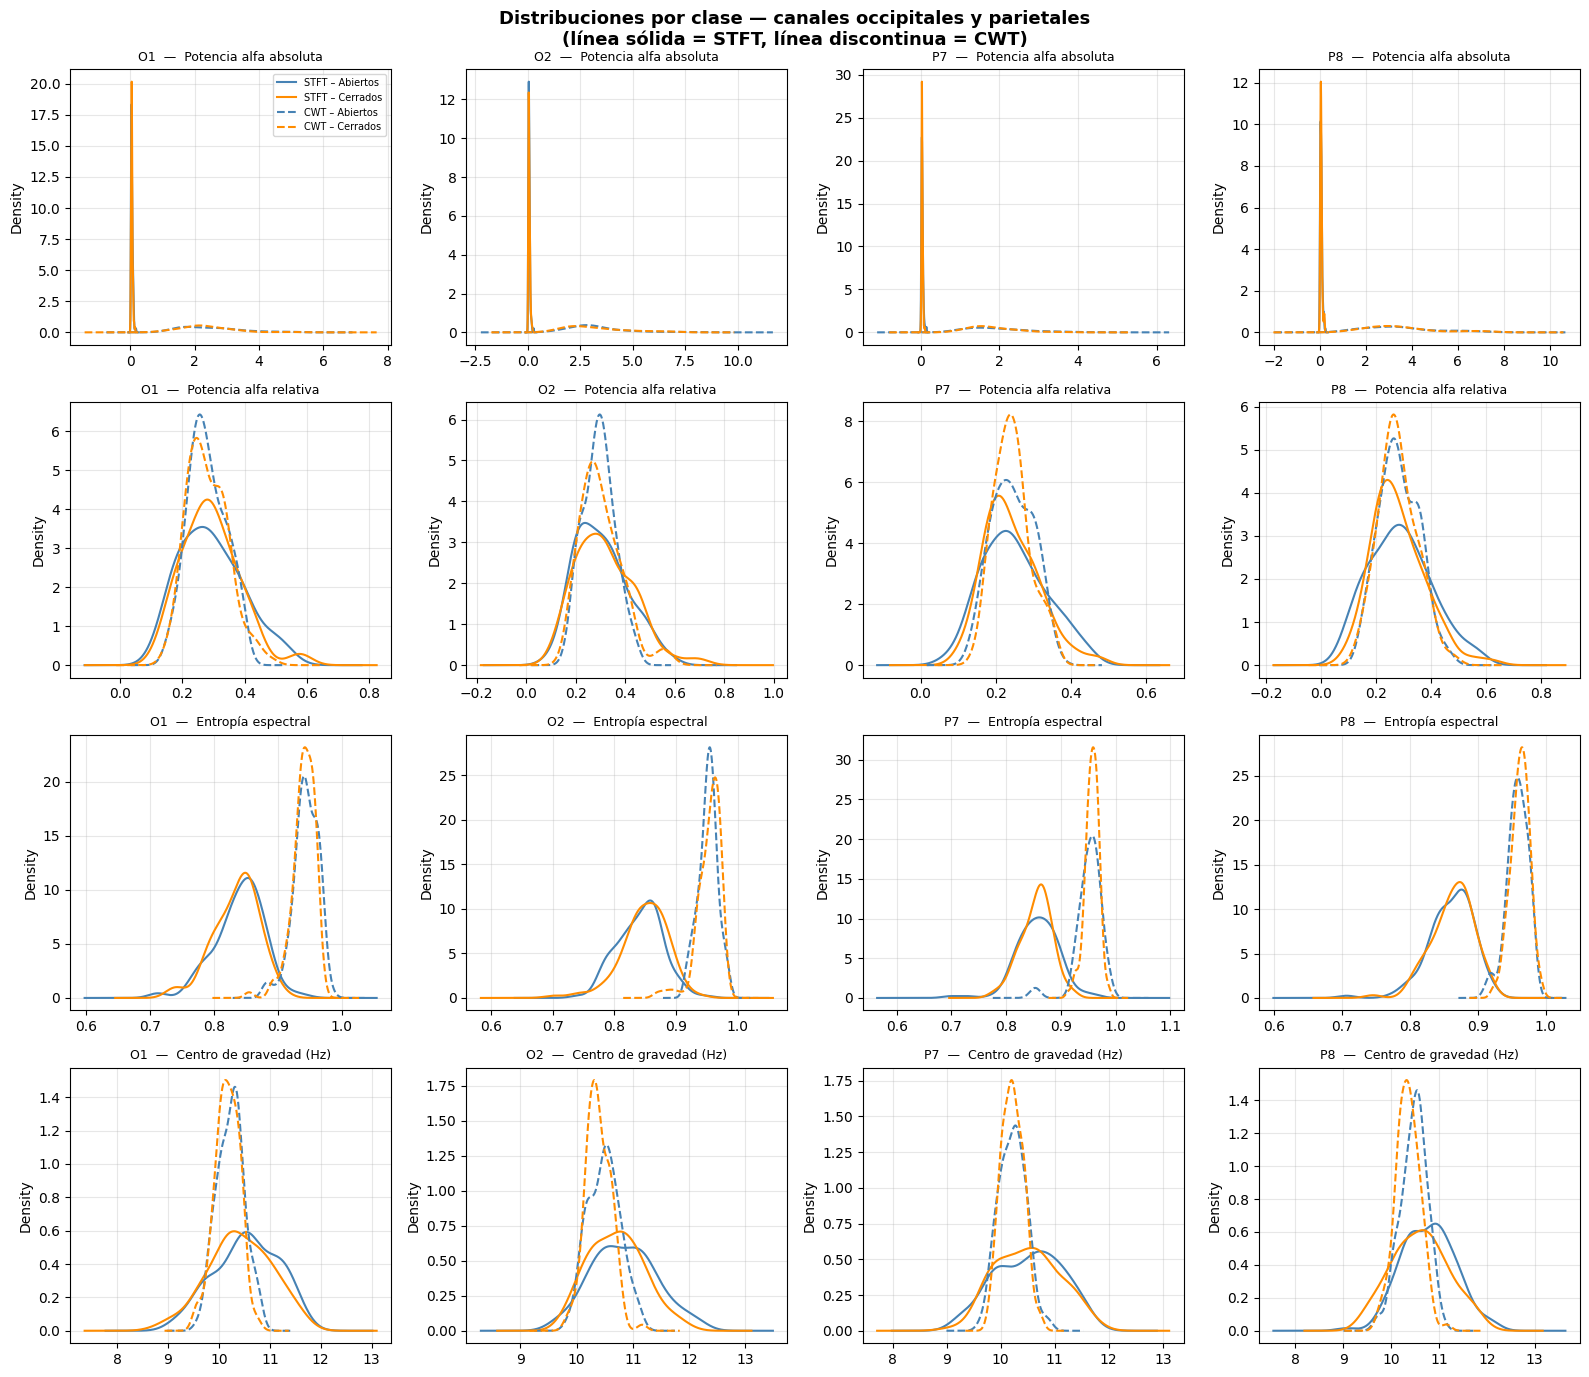

In [5]:
fig, axes = plt.subplots(len(FEAT_NAMES), len(OCC_CHANNELS),
                         figsize=(16, 14), sharey=False)

feat_labels = {
    'alpha_abs': 'Potencia alfa absoluta',
    'alpha_rel': 'Potencia alfa relativa',
    'entropy':   'Entropía espectral',
    'cog':       'Centro de gravedad (Hz)'
}

for row_i, feat in enumerate(FEAT_NAMES):
    for col_j, ch in enumerate(OCC_CHANNELS):
        ax  = axes[row_i, col_j]
        col = f'{ch}_{feat}'

        for name, df, ls in [('STFT', df_stft, '-'), ('CWT', df_cwt, '--')]:
            for cls, color, lbl in [(0, 'steelblue',  'Abiertos'),
                                    (1, 'darkorange', 'Cerrados')]:
                vals = df.loc[df['label'] == cls, col]
                vals.plot.kde(ax=ax, color=color, linestyle=ls,
                              linewidth=1.5,
                              label=f'{name} – {lbl}')

        ax.set_title(f'{ch}  —  {feat_labels[feat]}', fontsize=9)
        ax.set_xlabel('')
        ax.grid(True, alpha=0.3)

        # Leyenda solo en el primer panel
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Distribuciones por clase — canales occipitales y parietales\n'
             '(línea sólida = STFT, línea discontinua = CWT)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Nota sobre escalas: potencia alfa absoluta

La potencia alfa absoluta (`alpha_abs`) no es directamente comparable entre
STFT y CWT en términos de magnitud: la STFT produce valores en el orden de
$10^{-2}$ mientras que la CWT produce valores en el orden de $10^0$. Esta
diferencia no es un error — refleja que ambas representaciones operan en
unidades de potencia intrínsecamente distintas (la CWT no está normalizada
respecto al largo de la ventana de la misma forma que la STFT).

Por esta razón, `alpha_abs` se visualiza con paneles separados por técnica.
Las features `alpha_rel`, `entropy` y `cog` son adimensionales o tienen
rangos comparables entre técnicas y se visualizan en el mismo eje.

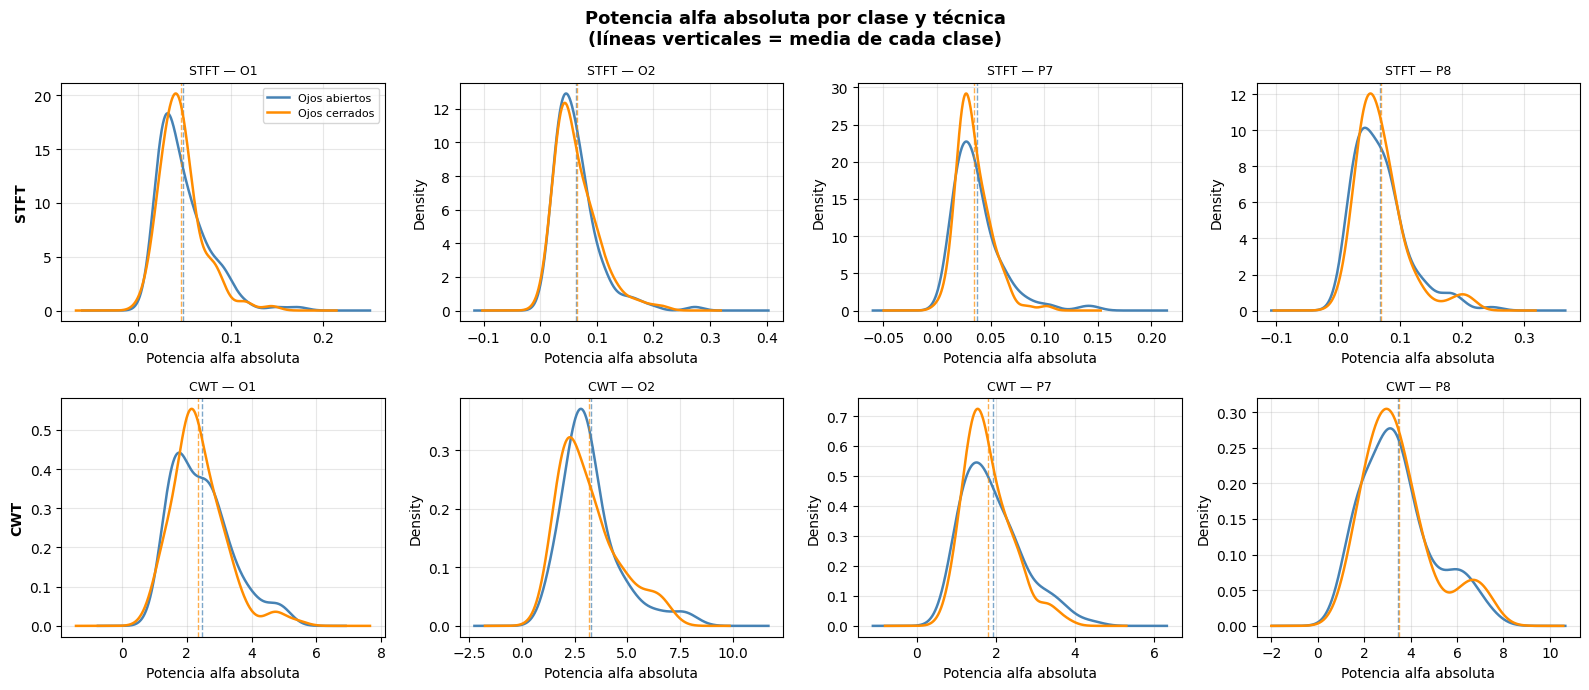

In [6]:
fig, axes = plt.subplots(2, len(OCC_CHANNELS), figsize=(16, 7), sharey=False)

for row_i, (name, df) in enumerate(TECHNIQUES):
    for col_j, ch in enumerate(OCC_CHANNELS):
        ax  = axes[row_i, col_j]
        col = f'{ch}_alpha_abs'

        for cls, color, lbl in [(0, 'steelblue',  'Ojos abiertos'),
                                 (1, 'darkorange', 'Ojos cerrados')]:
            vals = df.loc[df['label'] == cls, col]
            vals.plot.kde(ax=ax, color=color, linewidth=1.8, label=lbl)
            ax.axvline(vals.mean(), color=color, linestyle='--',
                       linewidth=1.0, alpha=0.7)

        ax.set_title(f'{name} — {ch}', fontsize=9)
        ax.set_xlabel('Potencia alfa absoluta')
        ax.grid(True, alpha=0.3)

        if col_j == 0:
            ax.set_ylabel(name, fontsize=10, fontweight='bold')
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=8)

plt.suptitle('Potencia alfa absoluta por clase y técnica\n'
             '(líneas verticales = media de cada clase)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

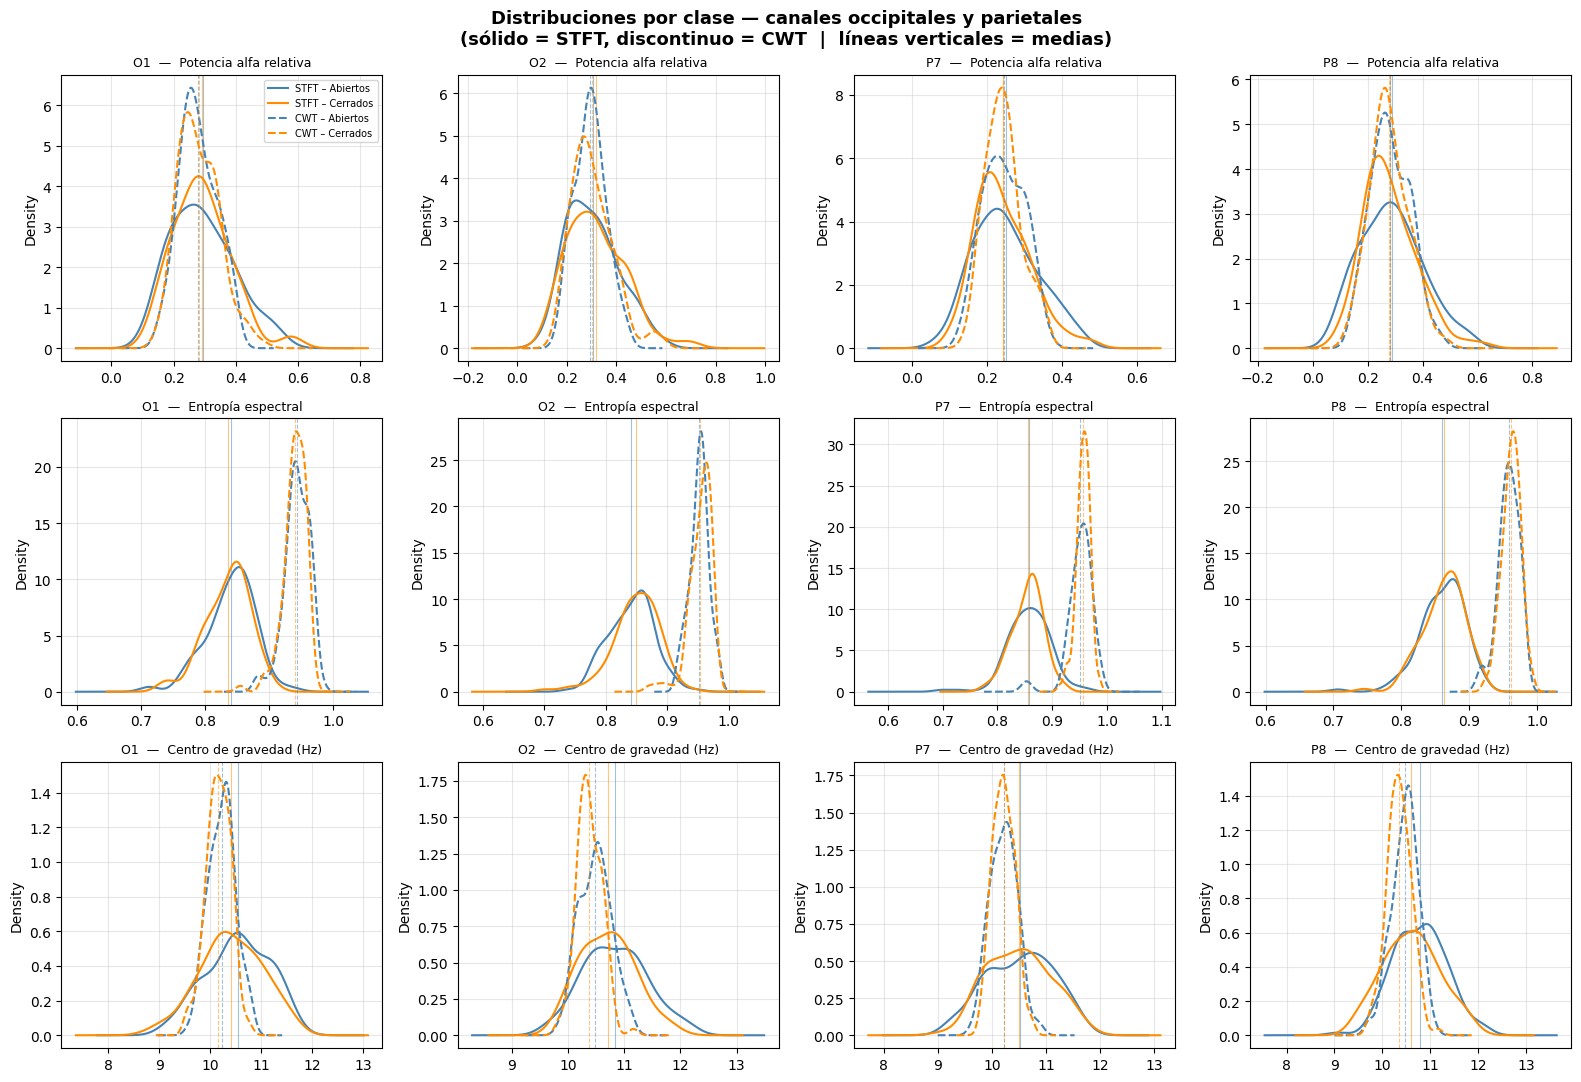

In [ ]:
FEAT_NAMES_VIZ = ['alpha_rel', 'entropy', 'cog']
feat_labels = {
    'alpha_rel': 'Potencia alfa relativa',
    'entropy':   'Entropía espectral',
    'cog':       'Centro de gravedad (Hz)'
}

fig, axes = plt.subplots(len(FEAT_NAMES_VIZ), len(OCC_CHANNELS),
                         figsize=(16, 11), sharey=False)

for row_i, feat in enumerate(FEAT_NAMES_VIZ):
    for col_j, ch in enumerate(OCC_CHANNELS):
        ax  = axes[row_i, col_j]
        col = f'{ch}_{feat}'

        for name, df, ls in [('STFT', df_stft, '-'), ('CWT', df_cwt, '--')]:
            for cls, color, lbl in [(0, 'steelblue',  'Abiertos'),
                                    (1, 'darkorange', 'Cerrados')]:
                vals = df.loc[df['label'] == cls, col]
                vals.plot.kde(ax=ax, color=color, linestyle=ls,
                              linewidth=1.5,
                              label=f'{name} – {lbl}')
                ax.axvline(vals.mean(), color=color, linestyle=ls,
                           linewidth=0.8, alpha=0.5)

        ax.set_title(f'{ch}  —  {feat_labels[feat]}', fontsize=9)
        ax.grid(True, alpha=0.3)

        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Distribuciones por clase — canales occipitales y parietales\n'
             '(sólido = STFT, discontinuo = CWT  |  '
             'líneas verticales = medias)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones visuales

**Potencia alfa absoluta (`alpha_abs`):** las distribuciones de ambas clases se
solapan casi completamente en todos los canales y técnicas, confirmando la baja
discriminabilidad de esta feature en escala absoluta. Los valores negativos que
aparecen en el eje x son un artefacto visual del estimador KDE, que extiende la
distribución más allá del cero; la potencia real no puede ser negativa.

**Potencia alfa relativa (`alpha_rel`):** la CWT produce distribuciones más
estrechas que la STFT — menor varianza — debido al suavizado temporal inherente
al promediado de 14980 muestras por ventana (vs los ~8 frames de la STFT). El
solapamiento entre clases es elevado en ambas técnicas.

**Entropía espectral (`entropy`):** es el panel más revelador. La STFT muestra
cierta separación entre clases con distribuciones amplias. La CWT, en cambio,
produce distribuciones extremadamente concentradas (varianza casi nula) en el
rango 0.94–0.96, haciendo que la entropía sea una feature casi constante y por
lo tanto poco útil como discriminador en esa técnica. Esta diferencia cualitativa
entre técnicas es un hallazgo metodológico relevante.

**Centro de gravedad (`cog`):** es la feature visualmente más prometedora.
La STFT muestra separación apreciable especialmente en O2 y P8. La dirección
es fisiológicamente consistente: ojos abiertos tiende a CoG más alto dentro de
la banda alfa, coherente con mayor presencia de actividad beta que desplaza el
centroide espectral hacia frecuencias superiores.

## Sección 3: Separabilidad por canal

Para cada feature, ¿qué canales muestran mayor diferencia entre clases? Se
visualiza la diferencia de medias normalizada por clase mediante boxplots de
los 14 canales, ordenados por posición anatómica. Se espera que los canales
occipitales (O1, O2) y parietales (P7, P8) dominen para features relacionadas
con el ritmo alfa.

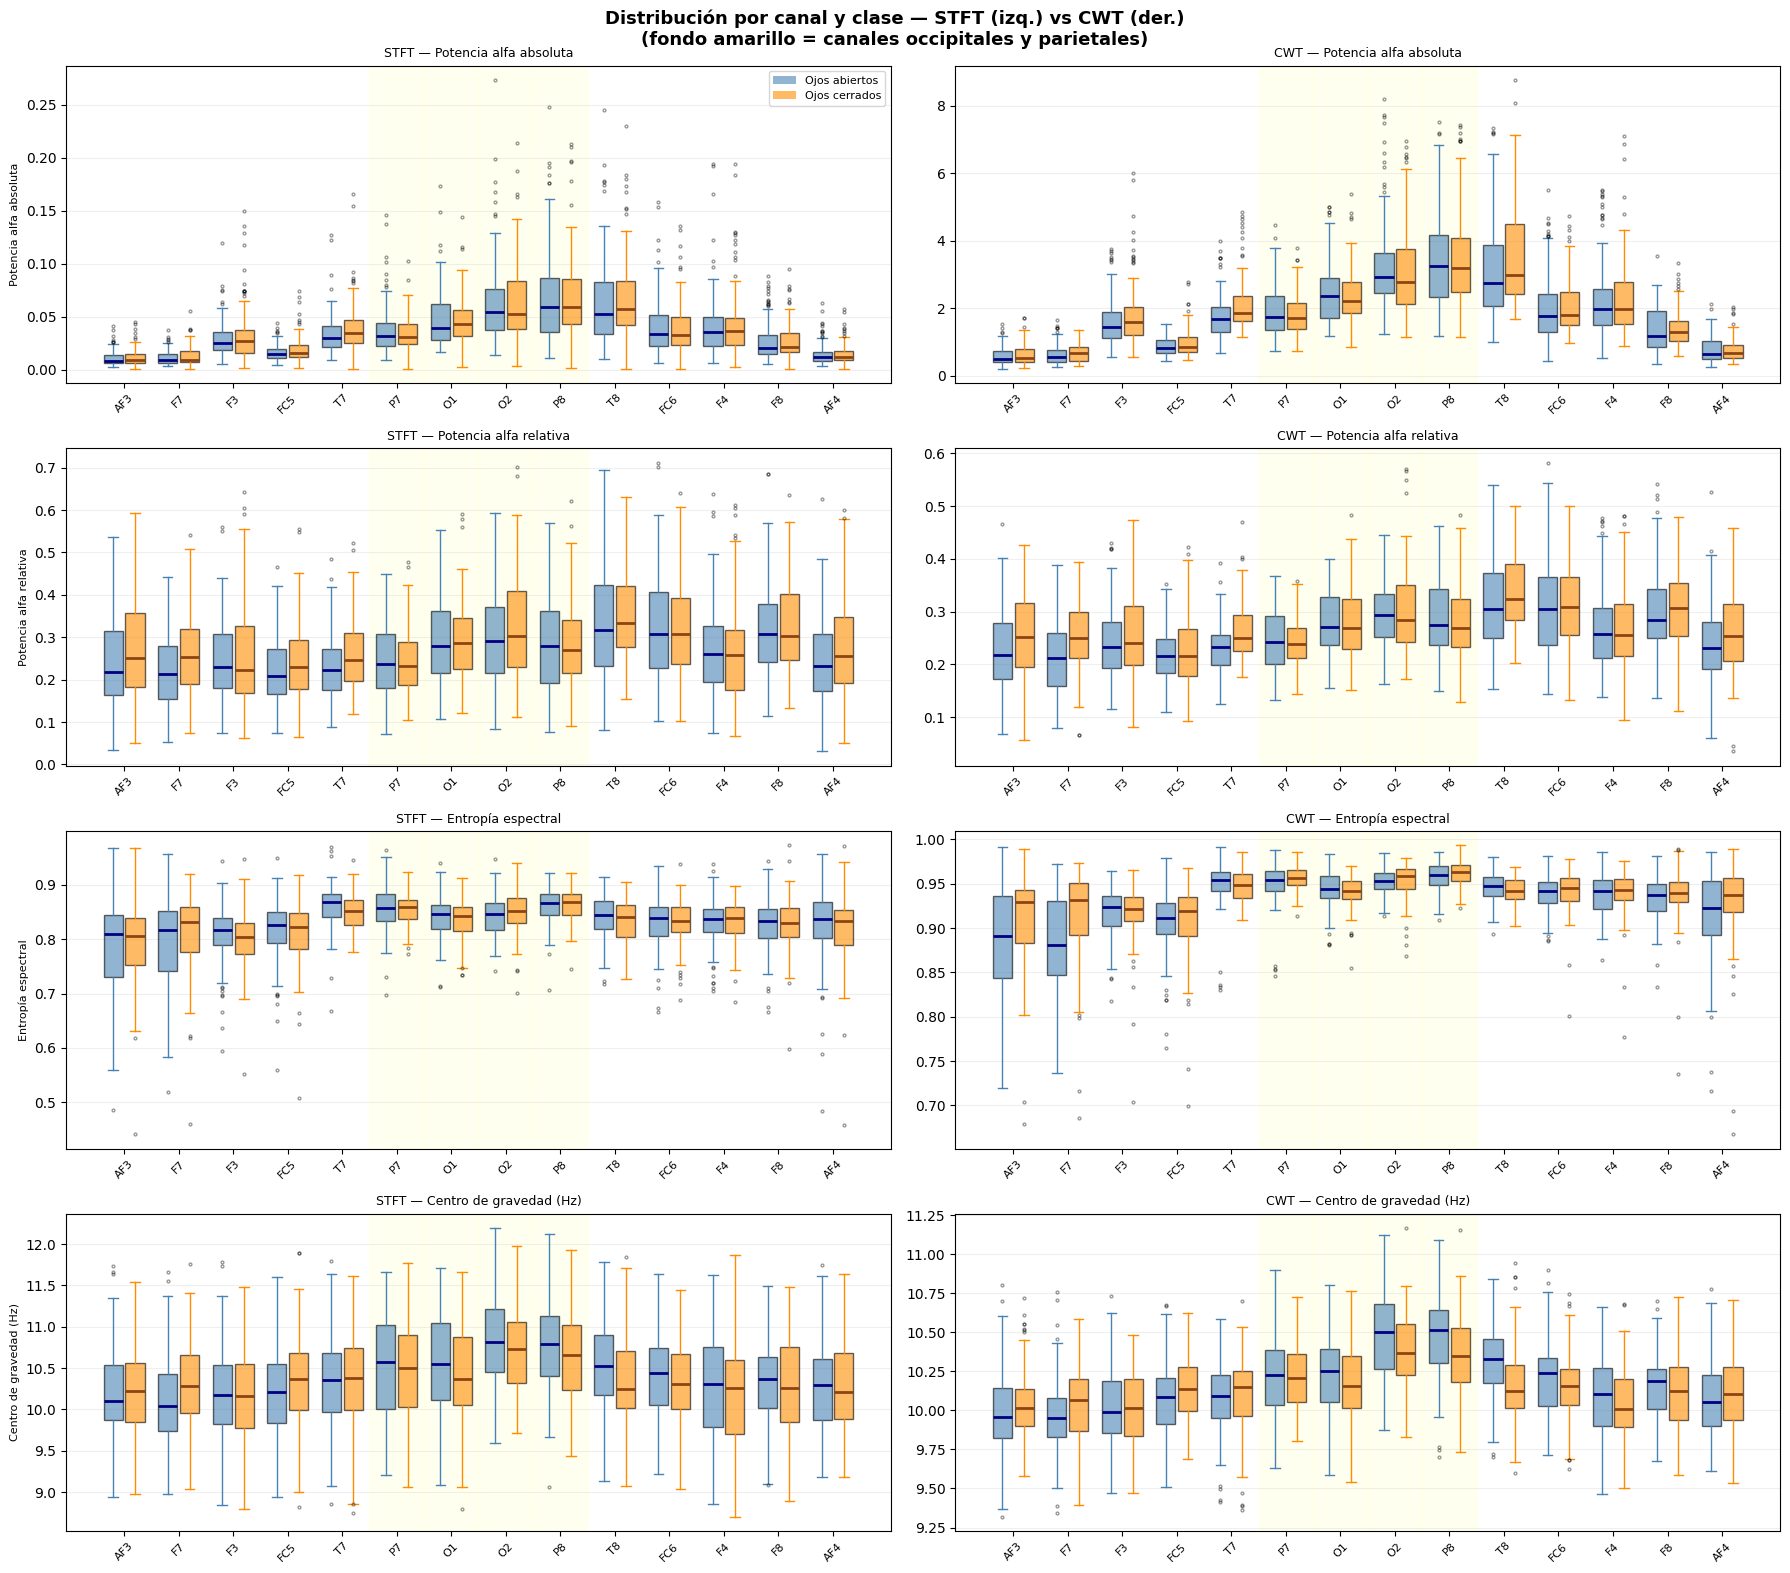

In [8]:
fig, axes = plt.subplots(len(FEAT_NAMES), 2, figsize=(18, 16), sharey=False)

feat_labels = {
    'alpha_abs': 'Potencia alfa absoluta',
    'alpha_rel': 'Potencia alfa relativa',
    'entropy':   'Entropía espectral',
    'cog':       'Centro de gravedad (Hz)'
}

for row_i, feat in enumerate(FEAT_NAMES):
    for col_j, (name, df) in enumerate(TECHNIQUES):
        ax = axes[row_i, col_j]

        data_cls0 = [df.loc[df['label']==0, f'{ch}_{feat}'].values for ch in CHANNELS]
        data_cls1 = [df.loc[df['label']==1, f'{ch}_{feat}'].values for ch in CHANNELS]

        positions_0 = np.arange(len(CHANNELS)) - 0.2
        positions_1 = np.arange(len(CHANNELS)) + 0.2

        bp0 = ax.boxplot(data_cls0, positions=positions_0, widths=0.35,
                         patch_artist=True, manage_ticks=False,
                         boxprops=dict(facecolor='steelblue', alpha=0.6),
                         medianprops=dict(color='navy', linewidth=2),
                         whiskerprops=dict(color='steelblue'),
                         capprops=dict(color='steelblue'),
                         flierprops=dict(marker='o', markersize=2,
                                         color='steelblue', alpha=0.4))

        bp1 = ax.boxplot(data_cls1, positions=positions_1, widths=0.35,
                         patch_artist=True, manage_ticks=False,
                         boxprops=dict(facecolor='darkorange', alpha=0.6),
                         medianprops=dict(color='saddlebrown', linewidth=2),
                         whiskerprops=dict(color='darkorange'),
                         capprops=dict(color='darkorange'),
                         flierprops=dict(marker='o', markersize=2,
                                         color='darkorange', alpha=0.4))

        # Marcar canales occipitales y parietales
        for i, ch in enumerate(CHANNELS):
            if ch in OCC_CHANNELS:
                ax.axvspan(i - 0.5, i + 0.5, color='lightyellow',
                           alpha=0.5, zorder=0)

        ax.set_xticks(range(len(CHANNELS)))
        ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
        ax.set_title(f'{name} — {feat_labels[feat]}', fontsize=9)
        ax.grid(True, alpha=0.2, axis='y')

        if col_j == 0:
            ax.set_ylabel(feat_labels[feat], fontsize=8)

        if row_i == 0 and col_j == 0:
            from matplotlib.patches import Patch
            ax.legend(handles=[
                Patch(facecolor='steelblue',  alpha=0.6, label='Ojos abiertos'),
                Patch(facecolor='darkorange', alpha=0.6, label='Ojos cerrados')
            ], fontsize=8)

plt.suptitle('Distribución por canal y clase — STFT (izq.) vs CWT (der.)\n'
             '(fondo amarillo = canales occipitales y parietales)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones — separabilidad por canal

**Topografía del alfa:** la potencia alfa absoluta es consistentemente mayor
en los canales occipitales y parietales (O1, O2, P7, P8) respecto a los
frontales, coherente con el predominio posterior del ritmo alfa. Esta
gradiente anatómica se observa en ambas técnicas, validando que las
representaciones TF capturan correctamente la distribución espacial esperada.

**Canal T8:** muestra valores de `alpha_abs` anómalamente altos en la CWT,
especialmente en ojos abiertos. Esto es inesperado anatómicamente (T8 es
temporal derecho) y sugiere contaminación por artefactos musculares en esa
región, que la CWT capta con mayor sensibilidad que la STFT debido a su
mayor resolución temporal.

**Entropía espectral en CWT:** todas las distribuciones se comprimen al rango
0.90–1.00 con varianza casi nula en todos los canales. Esto confirma que la
entropía es una feature prácticamente constante en la CWT,
independientemente del canal o del estado ocular, y por tanto **no aportará
poder discriminativo** en la etapa de clasificación para esa técnica.

**Centro de gravedad (`cog`):** es la feature que mejor respeta la anatomía y
la fisiología. La STFT muestra separación visible en O2 y P8, con ojos
abiertos tendiendo a un CoG levemente superior — dirección consistente con
la mayor presencia de actividad beta en el estado de alerta visual, que
desplaza el centroide hacia el límite superior de la banda alfa.

## Sección 4: Evolución temporal de features clave

¿Las features reflejan la dinámica del estado ocular a lo largo del tiempo?
Se grafica el valor de cada feature en los canales occipitales más
discriminativos (O1 y O2) contra el índice de ventana, coloreando por clase.
Si las features capturan correctamente el estado, deberían mostrar
diferencias sistemáticas en los segmentos de cada clase.

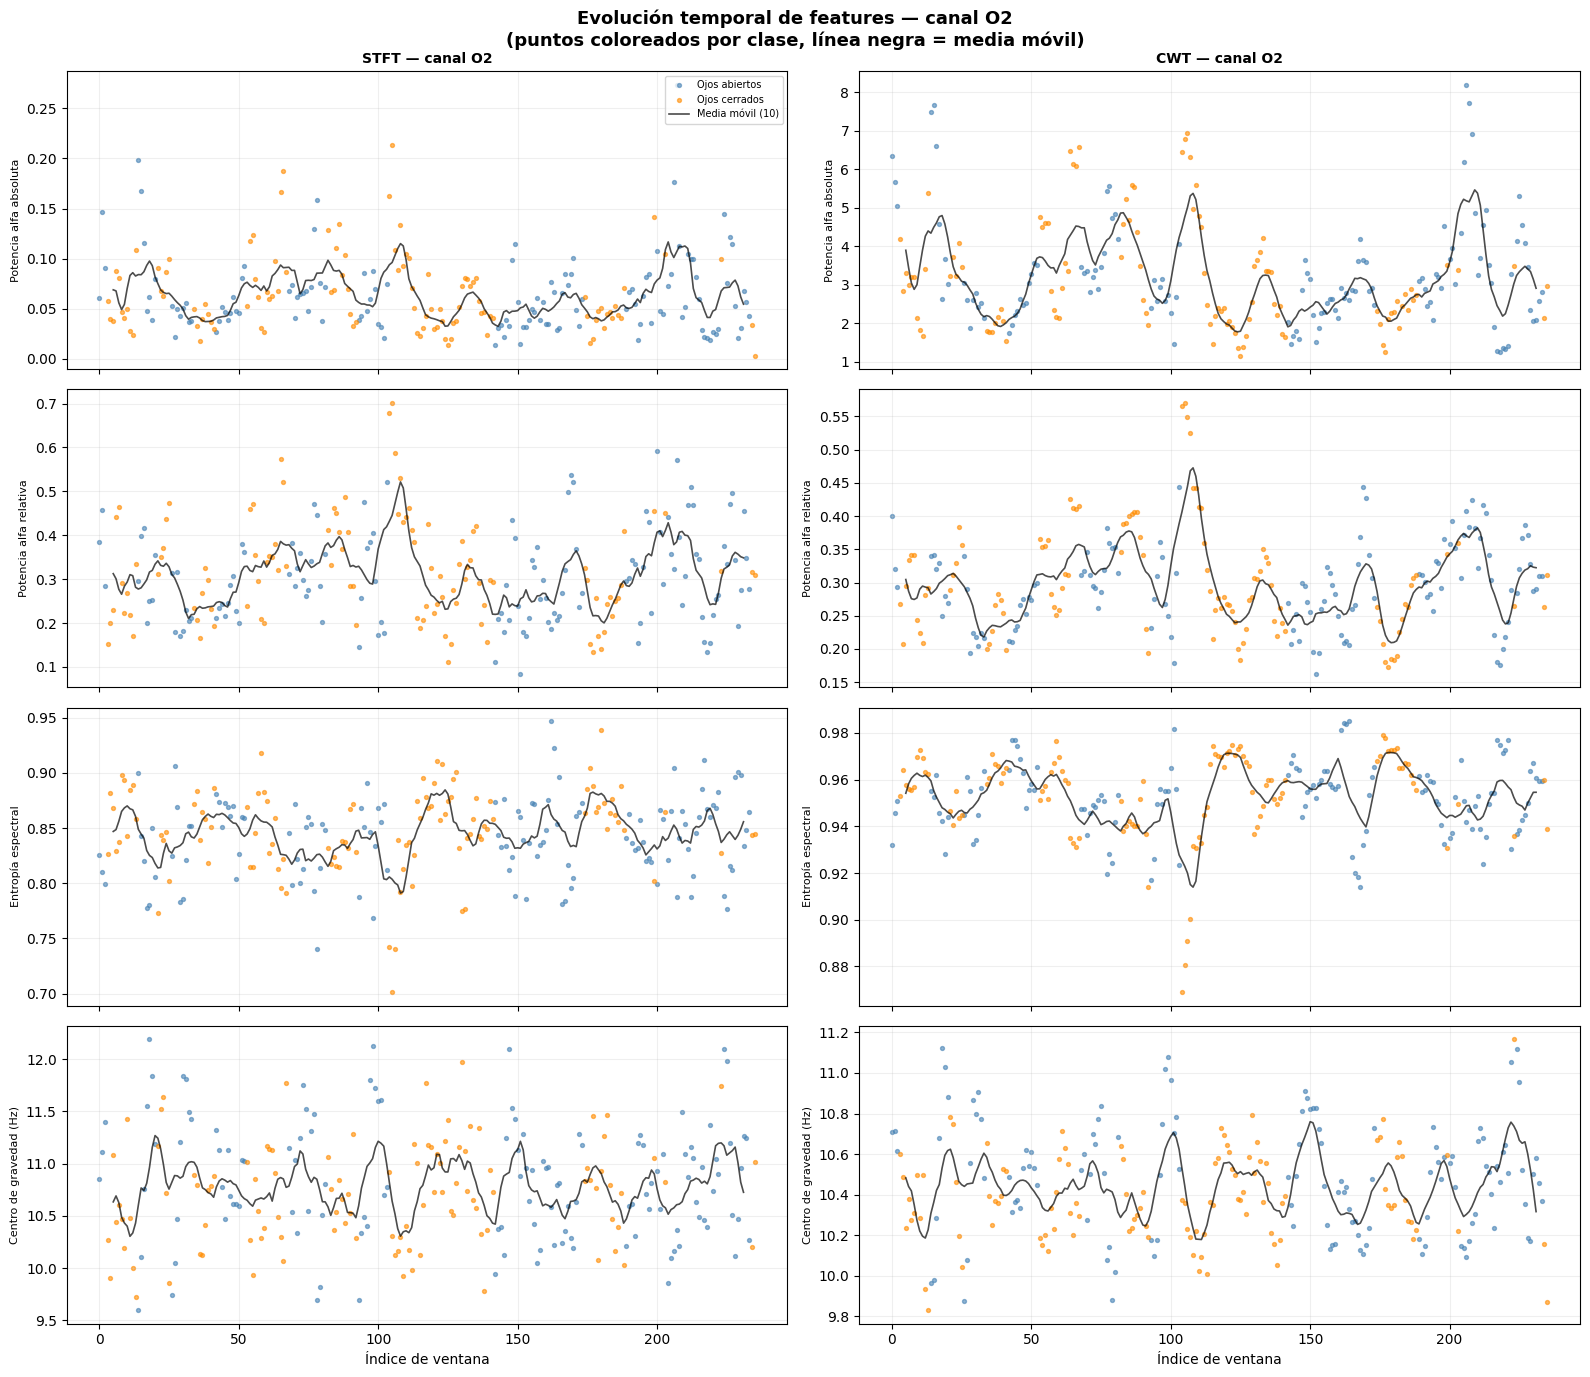

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)

feat_labels = {
    'alpha_abs': 'Potencia alfa absoluta',
    'alpha_rel': 'Potencia alfa relativa',
    'entropy':   'Entropía espectral',
    'cog':       'Centro de gravedad (Hz)'
}

ch_ref = 'O2'   # canal de referencia para evolución temporal

for row_i, feat in enumerate(FEAT_NAMES):
    for col_j, (name, df) in enumerate(TECHNIQUES):
        ax  = axes[row_i, col_j]
        col = f'{ch_ref}_{feat}'

        # Graficar cada ventana coloreada por clase
        for cls, color, lbl in [(0, 'steelblue',  'Ojos abiertos'),
                                 (1, 'darkorange', 'Ojos cerrados')]:
            idx  = df.index[df['label'] == cls]
            vals = df.loc[idx, col]
            ax.scatter(idx, vals, c=color, s=8, alpha=0.6, label=lbl)

        # Media móvil para ver tendencia
        ax.plot(df[col].rolling(window=10, center=True).mean(),
                color='black', linewidth=1.2, alpha=0.7, label='Media móvil (10)')

        ax.set_ylabel(feat_labels[feat], fontsize=8)
        ax.grid(True, alpha=0.2)

        if row_i == 0:
            ax.set_title(f'{name} — canal {ch_ref}', fontsize=10,
                         fontweight='bold')
        if row_i == len(FEAT_NAMES) - 1:
            ax.set_xlabel('Índice de ventana')
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle(f'Evolución temporal de features — canal {ch_ref}\n'
             '(puntos coloreados por clase, línea negra = media móvil)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones — evolución temporal

La evolución temporal confirma el diagnóstico previo: en todas las features
y ambas técnicas, los puntos de ambas clases aparecen completamente
entremezclados a lo largo del eje temporal. No existe ningún segmento del
registro donde una clase domine sistemáticamente sobre la otra en ninguna
de las features analizadas.

La media móvil muestra oscilaciones que no correlacionan con los cambios
de estado ocular — son fluctuaciones propias de la señal, no respuestas
al estímulo.

La única excepción parcial es el **centro de gravedad (CoG)**, donde los
puntos de ojos abiertos tienden a aparecer levemente por encima de los de
ojos cerrados de forma más consistente que en las otras features,
especialmente en la CWT. Este patrón, aunque sutil, es coherente con la
fisiología y es la señal más prometedora de todo el análisis exploratorio.

## Sección 5: Correlación entre features

¿Las 56 features aportan información independiente o son redundantes entre
sí? Una alta correlación entre features del mismo tipo (ej. `alpha_rel` en
distintos canales) sugiere que esos canales capturan el mismo fenómeno.
Una alta correlación entre features de distinto tipo (ej. `alpha_abs` y
`alpha_rel`) sugiere redundancia funcional.

Este análisis es relevante para anticipar qué clasificadores funcionarán
mejor: alta correlación favorece modelos que manejen multicolinealidad
(árboles, SVM con kernel RBF) sobre modelos lineales simples.

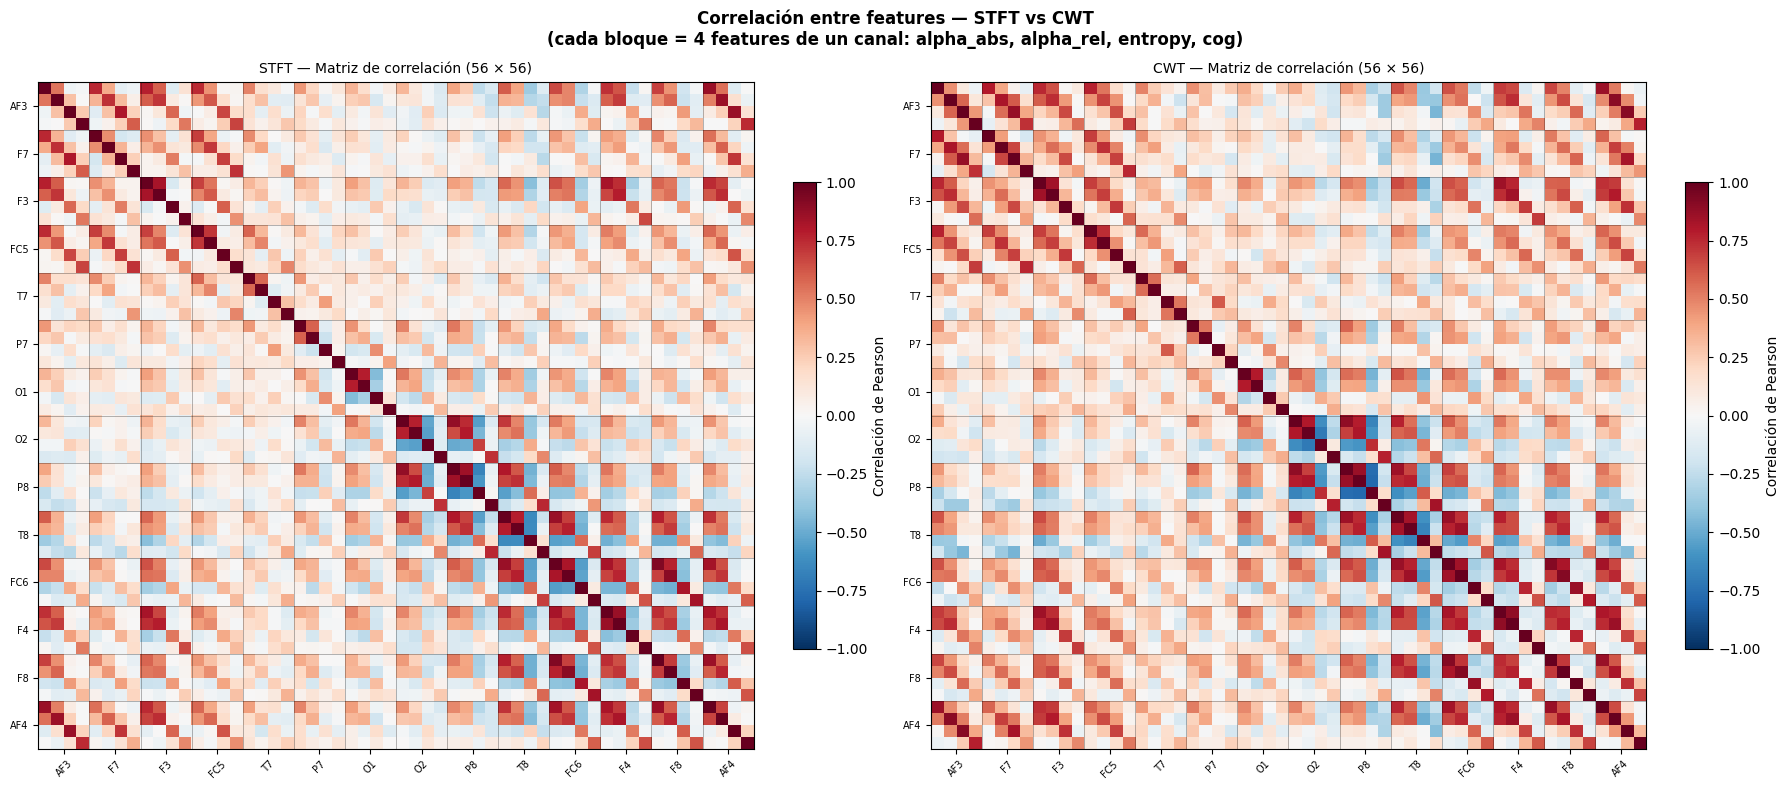

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (name, df) in zip(axes, TECHNIQUES):
    # Correlación solo entre features (sin la columna label)
    corr = df[COL_NAMES].corr()

    # Crear anotación de bloques por tipo de feature
    mask = np.zeros_like(corr, dtype=bool)

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

    # Líneas separando bloques de features por canal
    for i in range(1, len(CHANNELS)):
        ax.axhline(i * 4 - 0.5, color='black', linewidth=0.4, alpha=0.5)
        ax.axvline(i * 4 - 0.5, color='black', linewidth=0.4, alpha=0.5)

    # Líneas más gruesas separando tipos de feature
    for i in range(1, len(FEAT_NAMES)):
        # No aplica aquí porque features van agrupadas por canal
        pass

    # Etiquetas: solo mostrar canal (no cada feature individual)
    tick_positions = [i * 4 + 1.5 for i in range(len(CHANNELS))]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=7)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(CHANNELS, fontsize=7)

    ax.set_title(f'{name} — Matriz de correlación (56 × 56)', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.03, label='Correlación de Pearson')

plt.suptitle('Correlación entre features — STFT vs CWT\n'
             '(cada bloque = 4 features de un canal: '
             'alpha_abs, alpha_rel, entropy, cog)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones — matriz de correlación

**Estructura por bloques:** ambas matrices exhiben una estructura diagonal por
bloques clara: las 4 features de un mismo canal están correlacionadas entre sí,
lo cual es esperado dado que todas derivan del mismo espectro de potencia.

**Mayor globalidad en CWT:** la matriz CWT muestra regiones coloreadas fuera
de la diagonal más extensas que la STFT, indicando que las features CWT están
más correlacionadas entre canales. Esto es consecuencia del suavizado temporal
inherente al promediado de 14980 muestras por ventana en la CWT, que
homogeniza la información espectral entre electrodos.

**Correlaciones negativas:** aparecen en el cluster O1/O2/P8 vs T8 en ambas
matrices. Reflejan la relación inversa entre `alpha_rel` y `entropy`: cuando el
alfa domina el espectro (alta potencia relativa), la energía está concentrada y
la entropía es baja — y viceversa.

**Implicación para clasificación:** la alta correlación entre los canales
occipitales y parietales (O1, O2, P7, P8) indica redundancia parcial entre
sus features. Los clasificadores con regularización implícita (Random Forest,
SVM con kernel RBF) serán más robustos ante esta multicolinealidad que los
modelos lineales sin regularización.

## Síntesis del EDA

El análisis exploratorio caracterizó los dos datasets de features (STFT y CWT)
desde cuatro dimensiones. Los hallazgos más relevantes se resumen a continuación:

| Aspecto | STFT | CWT |
|---|---|---|
| Separabilidad por clase | Baja en todas las features | Baja en todas las features |
| Feature más prometedora | CoG (O2, P8) | CoG (O2, P8) |
| Entropía como discriminador | Moderada, con varianza real | Inutilizable (varianza ~0) |
| Varianza inter-clase | Mayor (distribuciones anchas) | Menor (distribuciones estrechas) |
| Correlación inter-canal | Moderada, estructura local | Alta, estructura global |
| Topografía del alfa | Correcta (posterior > frontal) | Correcta (posterior > frontal) |

### Conclusiones principales

1. **La baja discriminabilidad es consistente** entre ambas técnicas y todas las
   features, atribuible a la contaminación por artefactos EOG no removidos y a
   las limitaciones del hardware (Emotiv EPOC). Este no es un resultado negativo
   — es un hallazgo metodológico que contextualiza los resultados de clasificación.

2. **El CoG es la feature más informativa** en ambas técnicas, con dirección
   fisiológicamente correcta y mayor separación visual entre clases.

3. **La entropía espectral muestra un comportamiento cualitativamente distinto**
   entre técnicas: útil con varianza real en STFT, prácticamente constante e
   inutilizable en CWT. Esta diferencia cualitativa es en sí misma un resultado
   comparativo relevante.

4. **La CWT produce features más homogéneas** (menor varianza, mayor correlación
   inter-canal) mientras que la STFT produce features más dispersas. Cuál de
   estas propiedades favorece la clasificación se determinará en el notebook 05.

Estos hallazgos informarán directamente el diseño del análisis estadístico
comparativo (notebook 05) y la estrategia de clasificación (notebook 06).